**Professor:** Christian Mata Miquel

**Subject:** Data Analysis & Pattern Recognition

**Module:** Exploratory Data Analysis
https://github.com/adriafaneca-ops/Data-Analisis-Adria-Faneca.git

# **FLIPPED CLASSROOM (STUDENT VERSION)**

A flipped classroom is an instructional approach in which students first encounter new content on their own (e.g., via videos, readings, or online materials) before class, and then use class time for active, guided practice, problem solving, and discussion with the instructor's support.

### **Instructions**

This is **pre-class work**. Before the in-class session:

1. Review the theory notebook `Clustering_analysis_PRML` (k-means, hierarchical/agglomerative clustering, Gaussian Mixture Models, and evaluation metrics: confusion matrix, adjusted Rand score, BIC).
2. Complete the **3 exercises** below on your own. They combine skills from previous sessions:
   - **S1** (Python basics: functions, loops)
   - **S2.1** (pandas data handling, missing values, seaborn visualization)
   - **S3** (k-means, hierarchical clustering, GMM, evaluation metrics)
3. Bring your completed notebook (even if incomplete or with errors) and upload your solution to ATENEA (also share your GitHub link).
4. Three students will be randomly selected to present their solutions for Exercise 1, Exercise 2, and
Exercise 3. The student will come to present his solution and it will be discussed with all your classmates.

**No solutions are included here on purpose** — the goal is to try, get stuck, and bring your questions to class.

### **Before to start**

### Quick self-check before you start (answer in your own words, no need to submit)

- What is the main difference between k-means and hierarchical clustering in terms of how the number of clusters is chosen?
- Why can k-means fail on non-spherical or unevenly-sized clusters?
- What does the BIC criterion help us choose in a Gaussian Mixture Model?

If you can't answer these after reviewing the theory notebook, note it down — we'll start class with these questions.


---

## **Exercise 1:** K-means on the Penguins dataset (S2 + S3)

We'll reuse the `penguins` dataset from the S2 session (Palmer Archipelago penguins), and now apply clustering to it.

```python
import seaborn as sns
penguins = sns.load_dataset('penguins')
```

a) **(S2.1 recap)** Keep only the numeric columns (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`). Before dropping anything, **check how many missing values** each column has (`.isna().sum()`). Then drop rows with missing values (`.dropna()`) and **confirm the resulting dataframe is clean** (no `NaN` left).

b) **(normalization)** The four numeric columns live on very different scales (millimeters vs. grams). **Normalize them** with `StandardScaler` (mean 0, standard deviation 1) before clustering, since k-means uses Euclidean distance and would otherwise let `body_mass_g` dominate the result just because its raw values are much larger.

c) Apply **k-means** with `n_clusters=3` (there are 3 penguin species) to the **normalized** columns. Store the resulting labels in a variable `kmeans_labels`.

d) Add the cluster labels as a new column in your (unscaled) dataframe, and make a **scatterplot** (`bill_length_mm` vs `flipper_length_mm`) colored by `kmeans_labels`, as done in the S3 notebook and in S2.1. Also make two **pairplots** of the four numeric variables: one colored by the real `species`, and one colored by `kmeans_labels`, to visually compare them side by side (as done with `hue` in S2.1).

e) Now compare the clusters found by k-means with the **real species** (`species` column). Compute a **confusion matrix** (`sklearn.metrics.confusion_matrix`) between `kmeans_labels` and the real species, and the **adjusted Rand score** (`adjusted_rand_score`).

f) In a short comment or markdown cell: does k-means recover the 3 species well? Which species seem to get confused with each other, if any? Did normalizing the features change the result compared to using the raw values?

In [72]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

penguins = sns.load_dataset('penguins')
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# a) YOUR CODE HERE: check missing values per column, then dropna() and confirm the data is clean
print("Nule values before", penguins[num_cols].isna().sum())

penguins_clean = penguins.dropna(subset=num_cols + ['species']).copy()

print("Nule values after", penguins_clean[num_cols].isna().sum())

Nule values before bill_length_mm       2
bill_depth_mm        2
flipper_length_mm    2
body_mass_g          2
dtype: int64
Nule values after bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64


In [73]:
# b) YOUR CODE HERE: normalize the numeric columns with StandardScaler
penguins_scaled_df = None
scaler = StandardScaler()
penguins_scaled_array = scaler.fit_transform(penguins_clean[num_cols])
penguins_scaled_df = pd.DataFrame(penguins_scaled_array, columns=num_cols)

In [74]:
# c) YOUR CODE HERE: apply KMeans with n_clusters=3 on the normalized data
kmeans_labels = None
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(penguins_scaled_df)

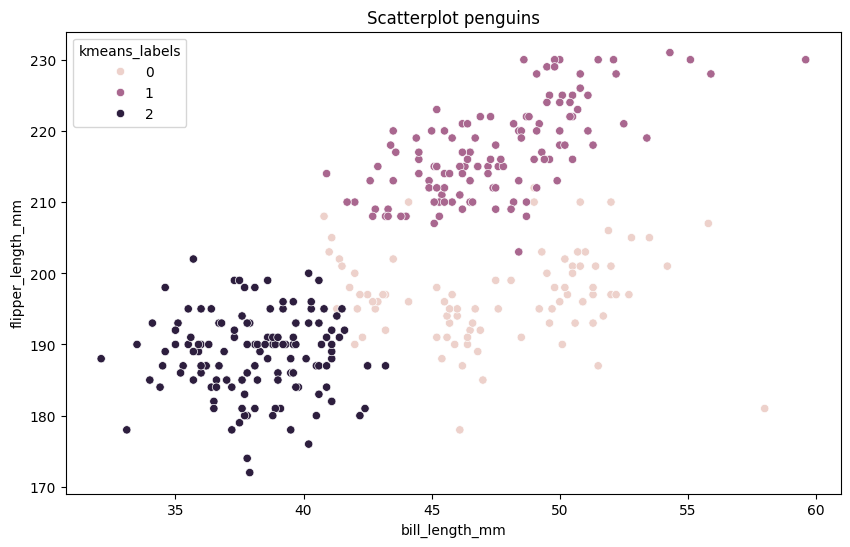

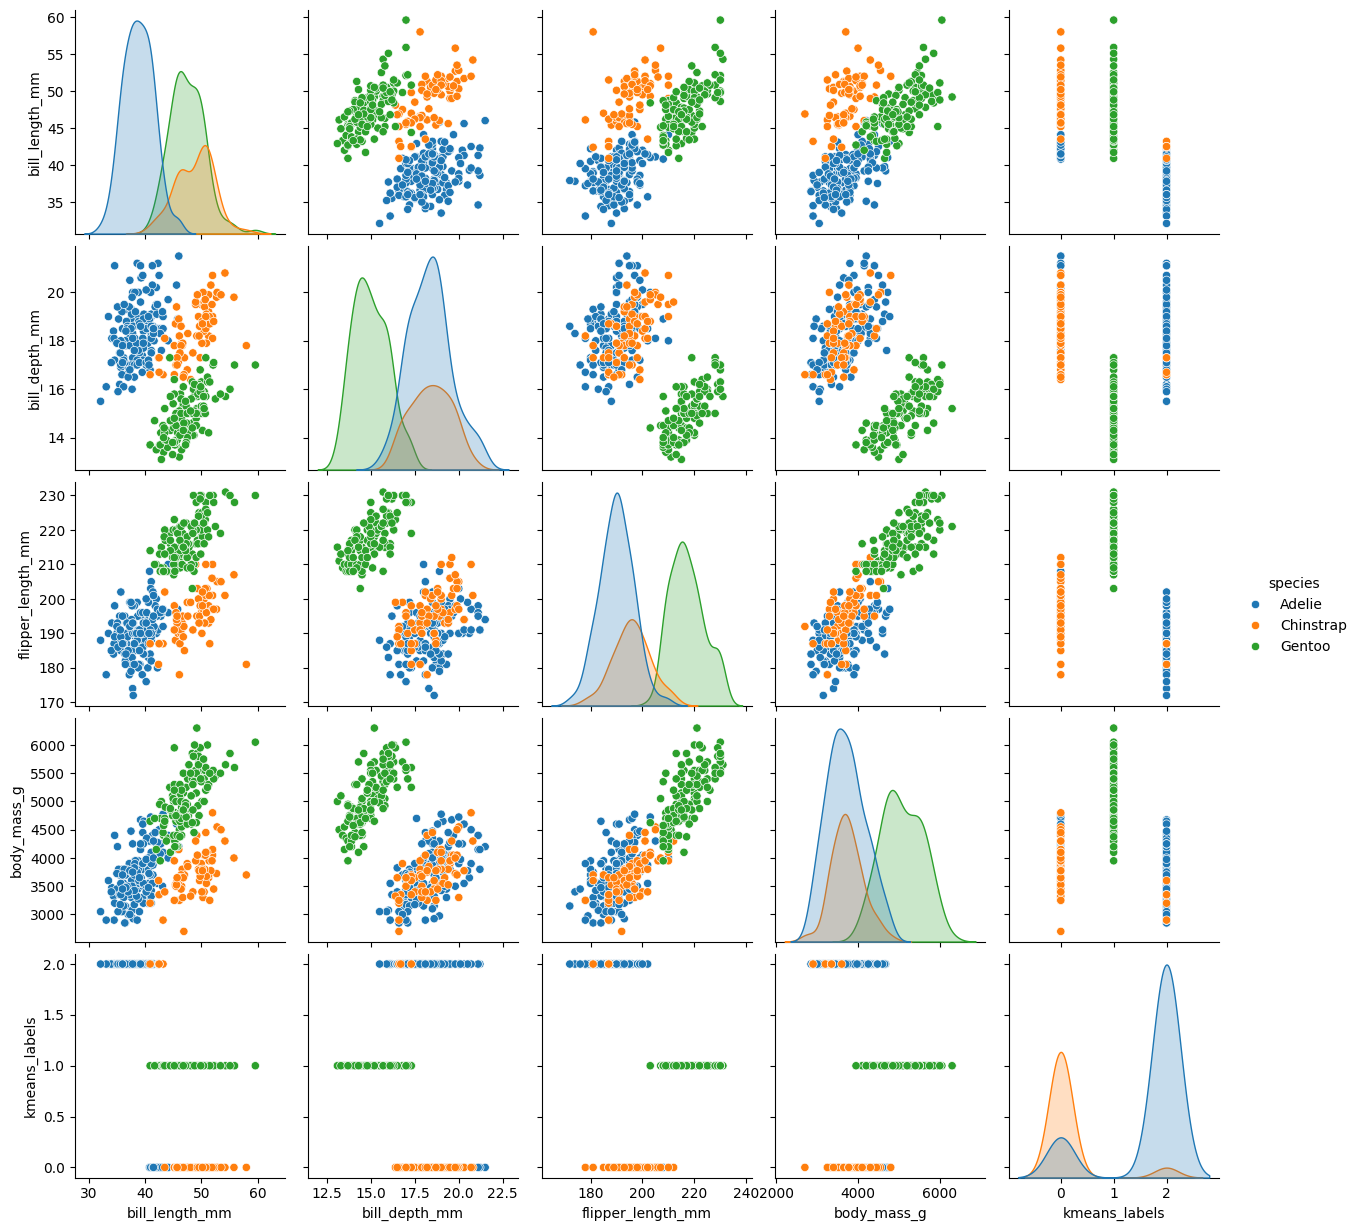

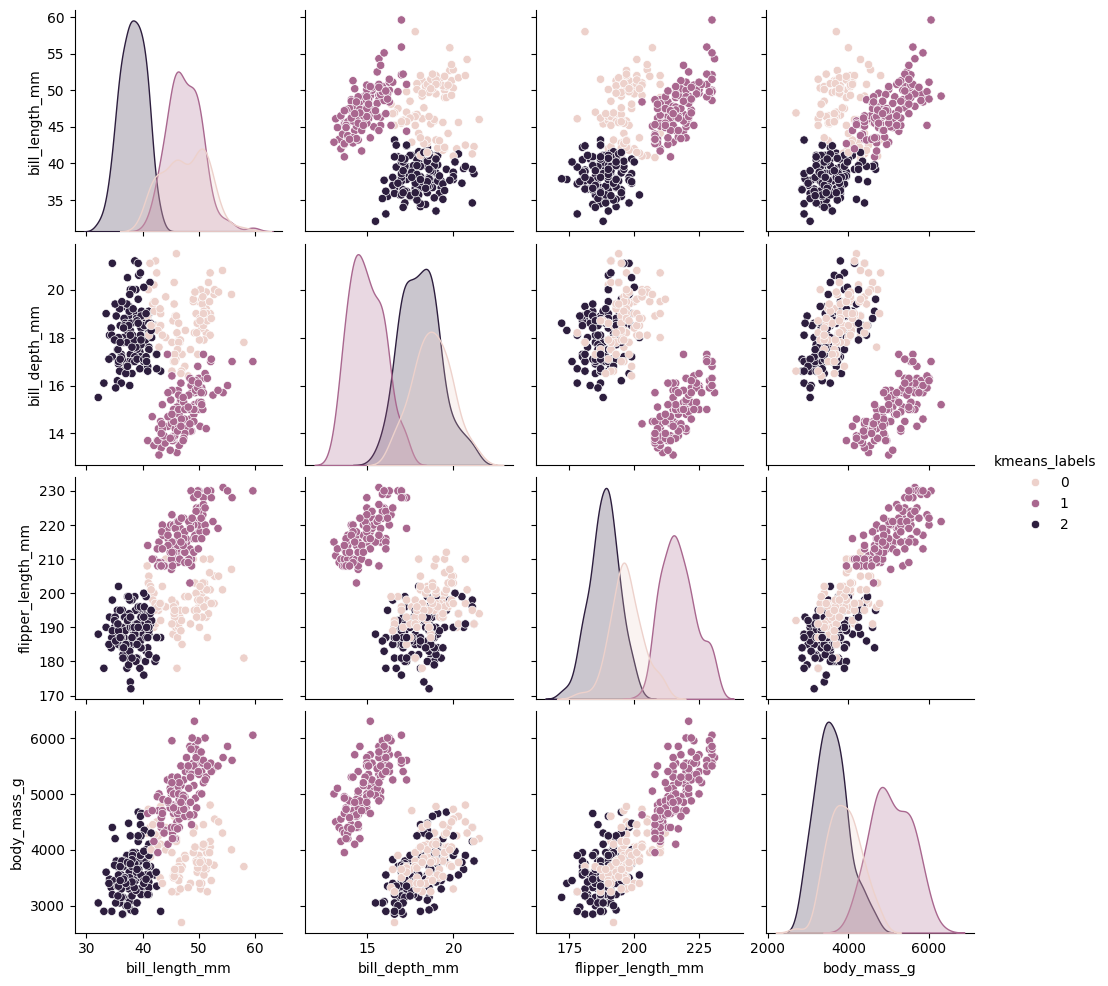

In [75]:
# d) YOUR CODE HERE: add kmeans_labels to penguins_clean, plot bill_length_mm vs flipper_length_mm colored by cluster,
#    and make two pairplots (one hue='species', one hue=kmeans cluster)
penguins_clean['kmeans_labels'] = kmeans_labels


fig = plt.figure(figsize=(10,6))
ax = sns.scatterplot(x="bill_length_mm", y="flipper_length_mm", hue="kmeans_labels", data=penguins_clean)
ax.set_title('Scatterplot penguins')
plt.show()

sns.pairplot(penguins_clean, hue='species')
plt.show()

sns.pairplot(penguins_clean, hue='kmeans_labels')
plt.show()



In [76]:
# e) YOUR CODE HERE: confusion matrix and adjusted Rand score vs real 'species'
# Encode the categorical 'species' to numeric codes so they match the type of 'kmeans_labels'
le = LabelEncoder()
species_encoded = le.fit_transform(penguins_clean['species'])

matrix_confusion = confusion_matrix(species_encoded, penguins_clean['kmeans_labels'])
rand_score = adjusted_rand_score(species_encoded, penguins_clean['kmeans_labels'])

print("Confusion matrix:", matrix_confusion)
print("Adjusted rand score:", rand_score)

Confusion matrix: [[ 24   0 127]
 [ 63   0   5]
 [  0 123   0]]
Adjusted rand score: 0.7928369051321087


In [77]:
# The algorithm identifies the three species.
# K-means confuses Adelie and Chinstrap penguins because these two birds share identical physical dimensions that the mathematical model fails to separate correctly when measuring the resulting clusters.
# The Gentoo penguins remain isolated.
# Normalizing the numeric variables alters the final result because this step prevents the heavy body mass metric from completely overriding the other three physical measurements.
# The system calculates distances.
# Magnitudes in thousands of grams crush lengths in tens of millimeters if you omit the preparation process before running the machine learning clustering code.

## **Exercise 2:** Hierarchical clustering + a custom distance function (S1 + S3)

We'll use the small synthetic dataset from the S3 notebook:

```python
import numpy as np
X = np.array([[1, 2], [1, 4], [1, 0], [5, 6], [5, 3], [5, 0]])
```

a) **(control de datos)** Even on a small synthetic array like this one, it's good practice to check for missing values before doing anything else: use `np.isnan(X).any()` to confirm there are none.

b) **(normalization)** Normalize `X` with `StandardScaler` before clustering (even though both coordinates here happen to be on a similar scale, this should always be the default first step for any distance-based method, so that you don't forget it on a real dataset where scales usually differ a lot).

c) **(S1 recap)** Write a plain Python function `euclidean_distance(p1, p2)` **without using numpy or sklearn**, using only a `for` loop over the coordinates, that computes the Euclidean distance between two points (given as lists or tuples). Test it on `euclidean_distance(X[0], X[3])` and check it against `np.linalg.norm(X[0]-X[3])`.

d) Apply **Agglomerative Clustering** with `n_clusters=2` to the **normalized** `X` (as done in the S3 notebook), and plot the **dendrogram** using `scipy.cluster.hierarchy.dendrogram` and `linkage`.

e) Also apply **k-means** with `n_clusters=2` to the same normalized data.

f) Compare the cluster labels obtained by agglomerative clustering and k-means — are they identical for this small dataset? (Print both label arrays, and make a side-by-side scatterplot of the original points colored by each method's labels.)

g) **(S1 recap)** Write a function `cluster_sizes(labels)` that takes an array of cluster labels and returns a **dictionary** with the count of observations per cluster (reuse the dictionary-counting pattern from S1), and apply it to both clusterings.

In [78]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

X = np.array([[1, 2], [1, 4], [1, 0], [5, 6], [5, 3], [5, 0]])

# a) YOUR CODE HERE: check for missing values with np.isnan(X).any()
print("Missing values:", np.isnan(X).any())


Missing values: False


In [79]:
# b) YOUR CODE HERE: normalize X with StandardScaler
X_scaled = None
X_scaled = scaler.fit_transform(X)

In [80]:
# c) YOUR CODE HERE: plain-Python euclidean_distance function using a for loop (no numpy/sklearn)
def euclidean_distance(p1, p2):
    squared_dist = 0
    for i in range(len(p1)):
        squared_dist += (p1[i] - p2[i]) ** 2
    return squared_dist ** 0.5

# test it
print("Custom distance:", euclidean_distance(X[0], X[3]))
print("Numpy distance:", np.linalg.norm(X[0] - X[3]))

Custom distance: 5.656854249492381
Numpy distance: 5.656854249492381


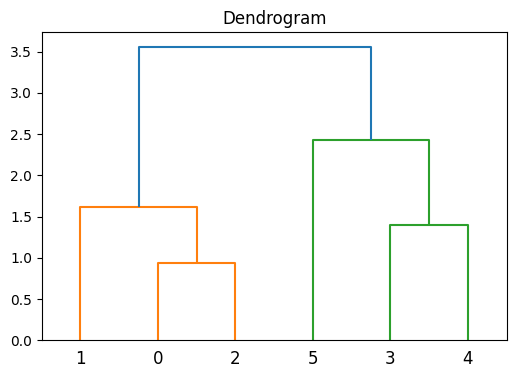

In [81]:
# d) YOUR CODE HERE: agglomerative clustering on X_scaled + dendrogram
agglo = AgglomerativeClustering(n_clusters=2)
agglo_labels = agglo.fit_predict(X_scaled)

linked = linkage(X_scaled, method='ward')
plt.figure(figsize=(6, 4))
dendrogram(linked)
plt.title('Dendrogram')
plt.show()

In [82]:
# e) YOUR CODE HERE: k-means clustering with n_clusters=2 on X_scaled
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

Agglomerative labels: [1 1 1 0 0 0]
K-Means labels: [0 0 0 1 1 1]


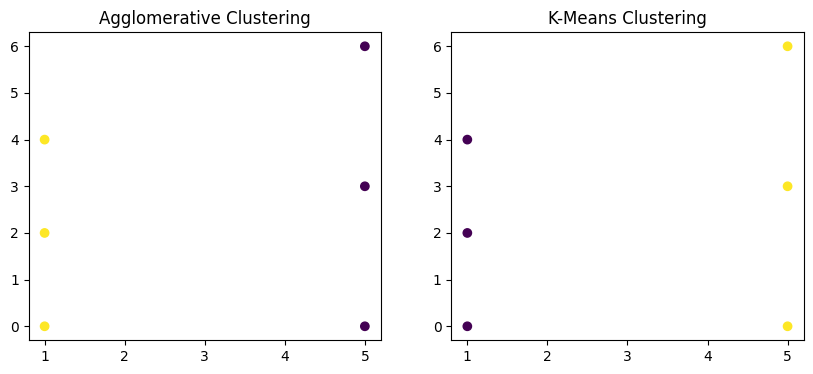

In [83]:
# f) YOUR CODE HERE: compare both label arrays and make a side-by-side scatterplot
print("Agglomerative labels:", agglo_labels)
print("K-Means labels:", kmeans_labels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(X[:, 0], X[:, 1], c=agglo_labels, cmap='viridis')
ax1.set_title('Agglomerative Clustering')
ax2.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
ax2.set_title('K-Means Clustering')
plt.show()

In [84]:
# g) YOUR CODE HERE: cluster_sizes function using a dictionary
def cluster_sizes(labels):
    counts = {}
    for label in labels:
        counts[label] = counts.get(label, 0) + 1
    return counts

print("Agglomerative sizes:", cluster_sizes(agglo_labels))
print("K-Means sizes:", cluster_sizes(kmeans_labels))

Agglomerative sizes: {np.int64(1): 3, np.int64(0): 3}
K-Means sizes: {np.int32(0): 3, np.int32(1): 3}


---

## **Exercise 3:** Choosing the number of clusters with GMM + BIC (S1+S2+S3)

We'll reuse the `diamonds` sample from the S2.1 session:

```python
diamonds = sns.load_dataset('diamonds').sample(1000, random_state=42)
```

a) **(S2 recap)** Select only the numeric columns `carat`, `depth`, `table`, `price` into a new dataframe `diamonds_num`. **Check for missing values** (`.isna().sum()`) and drop any rows with `NaN` if needed, confirming the data is clean afterwards.

b) **(exploración, opcional pero recomendado)** Plot the distribution of `price` (histogram) and mark the mean and mean ± one standard deviation with vertical lines, as done in S2.1 — this helps you see just how skewed and large-scale `price` is compared to the other three variables.

c) **(normalization)** `carat`, `depth`, `table` and `price` are on very different scales (price ranges into the thousands of dollars, while depth/table are percentages around 50–70). **Normalize all four columns with `StandardScaler`** before fitting the GMM — otherwise `price` alone will dominate the covariance structure the model is trying to fit.

d) As done in the S3 notebook, fit a **Gaussian Mixture Model** on the **normalized** data for a range of number of components from 1 to 8, store the **BIC** value for each in a list, and plot BIC vs number of components.

e) Find the number of components that **minimizes** the BIC, and fit the final GMM model with that number of components. Store the predicted cluster labels in `gmm_labels`.

f) Add `gmm_labels` as a new column to your (unscaled, more interpretable) `diamonds_num` and create a **pairplot** (`sns.pairplot`) of `carat`, `depth`, `table`, `price`, colored by `gmm_labels` (`hue`), as done in S2.1. Also make a **jointplot** (`sns.jointplot`) of `carat` vs `price` to zoom into the relationship driving most of the clustering.

g) In a short comment or markdown cell: does the optimal number of clusters found by BIC seem reasonable when you look at the pairplot? Would you have guessed the same number just by eye? Did normalizing the data change the optimal number of components compared to fitting the GMM on the raw values?

In [85]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import mixture
from sklearn.preprocessing import StandardScaler

diamonds = sns.load_dataset('diamonds').sample(1000, random_state=42)

# a) YOUR CODE HERE: select numeric columns into diamonds_num, check missing values, dropna() and confirm it's clean
cols = ['carat', 'depth', 'table', 'price']
diamonds_num = diamonds[cols].copy()
print("Missing values before:\n", diamonds_num.isna().sum())
diamonds_num = diamonds_num.dropna()
print("Missing values after:\n", diamonds_num.isna().sum())

Missing values before:
 carat    0
depth    0
table    0
price    0
dtype: int64
Missing values after:
 carat    0
depth    0
table    0
price    0
dtype: int64


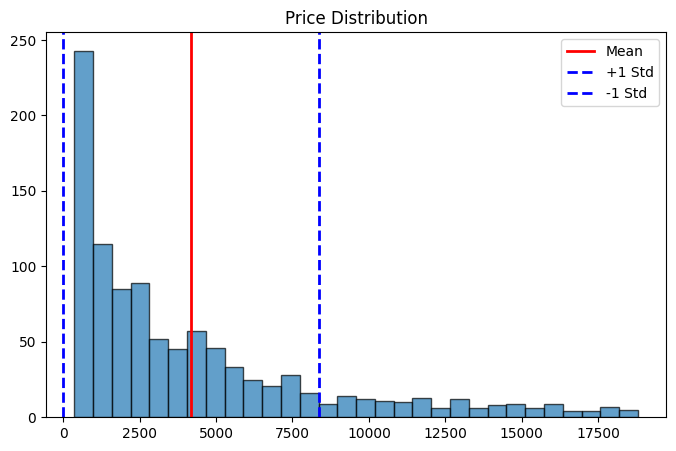

In [86]:
# b) YOUR CODE HERE: histogram of 'price' with mean and mean +/- std lines
price_mean = diamonds_num['price'].mean()
price_std = diamonds_num['price'].std()

plt.figure(figsize=(8, 5))
plt.hist(diamonds_num['price'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(price_mean, color='red', linestyle='solid', linewidth=2, label='Mean')
plt.axvline(price_mean + price_std, color='blue', linestyle='dashed', linewidth=2, label='+1 Std')
plt.axvline(price_mean - price_std, color='blue', linestyle='dashed', linewidth=2, label='-1 Std')
plt.title('Price Distribution')
plt.legend()
plt.show()

In [87]:
# c) YOUR CODE HERE: normalize the 4 numeric columns with StandardScaler
scaler = StandardScaler()
diamonds_scaled = scaler.fit_transform(diamonds_num)

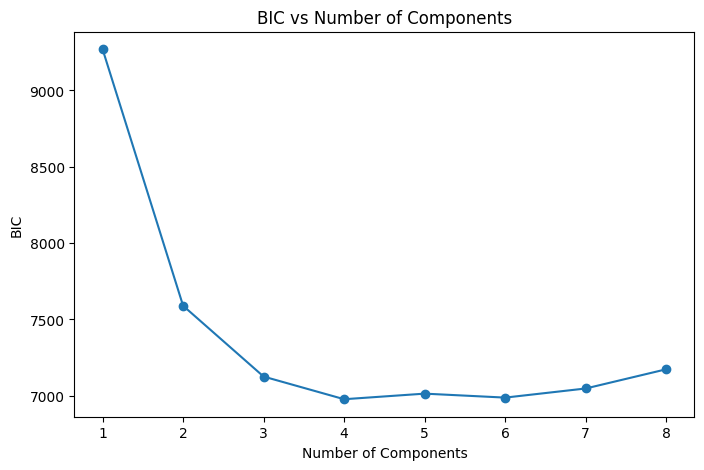

In [88]:
# d) YOUR CODE HERE: fit GMM for n_components = 1..8 on diamonds_scaled, store BIC values, plot BIC vs n_components
bic = []
n_components_range = range(1, 9)

for n in n_components_range:
    gmm = mixture.GaussianMixture(n_components=n, random_state=42)
    gmm.fit(diamonds_scaled)
    bic.append(gmm.bic(diamonds_scaled))

plt.figure(figsize=(8, 5))
plt.plot(n_components_range, bic, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('BIC')
plt.title('BIC vs Number of Components')
plt.show()

In [89]:
# e) YOUR CODE HERE: find the number of components that minimizes BIC and fit the final GMM
best_n = n_components_range[np.argmin(bic)]
print("Optimal number of components:", best_n)
best_gmm = mixture.GaussianMixture(n_components=best_n, random_state=42)
gmm_labels = best_gmm.fit_predict(diamonds_scaled)

Optimal number of components: 4


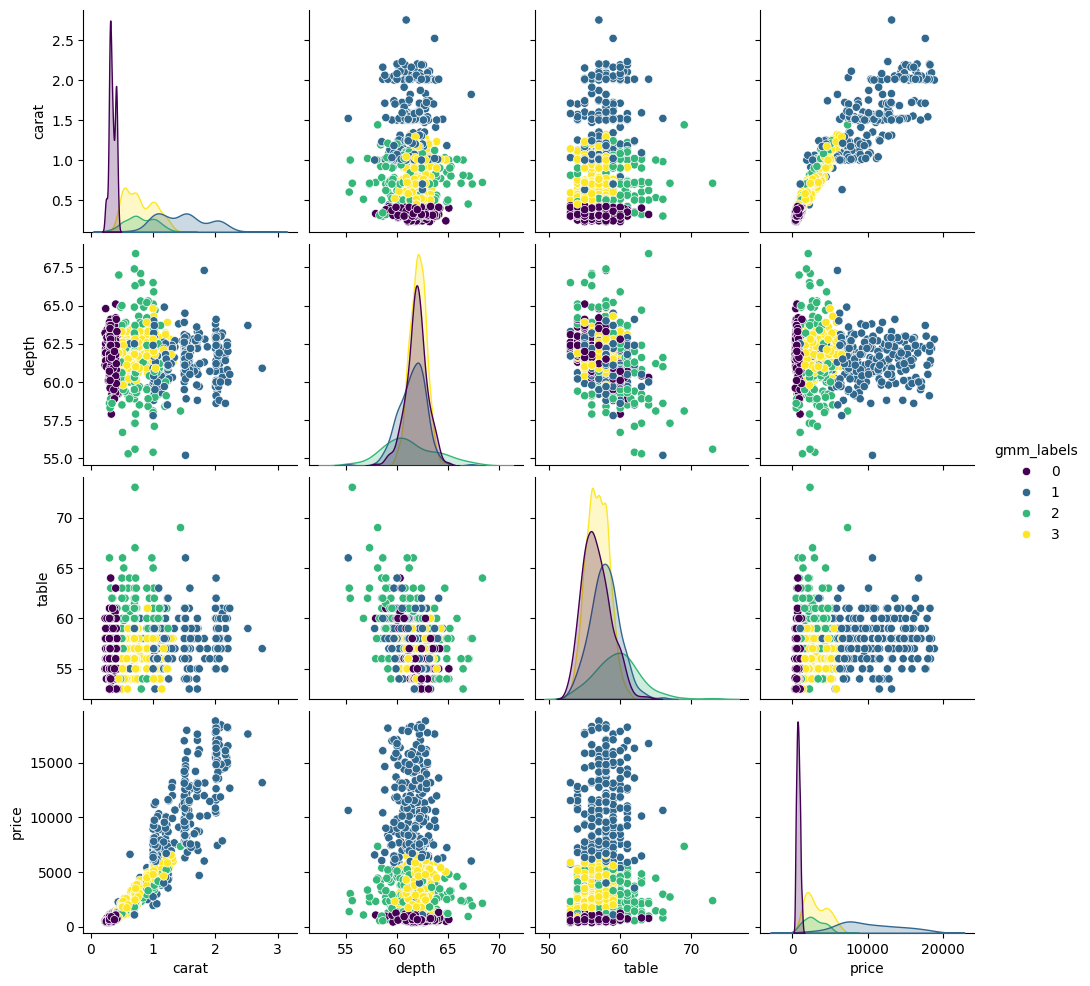

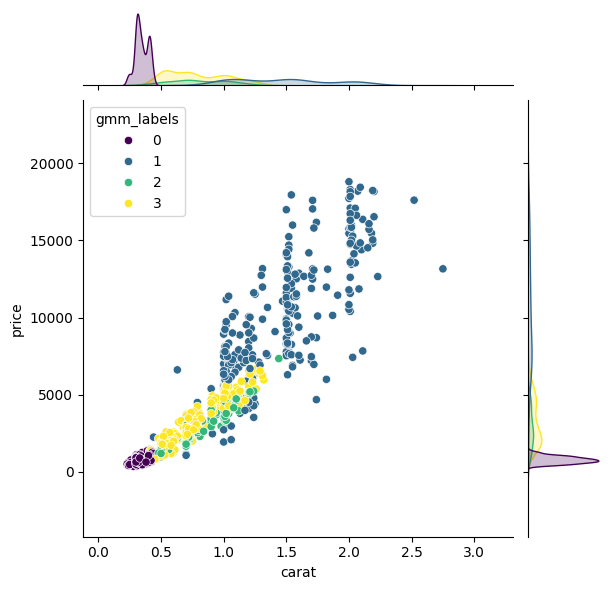

In [90]:
# f) YOUR CODE HERE: add gmm_labels to diamonds_num (unscaled) and make a pairplot + a jointplot (carat vs price)
diamonds_num['gmm_labels'] = gmm_labels

sns.pairplot(diamonds_num, vars=cols, hue='gmm_labels', palette='viridis')
plt.show()

sns.jointplot(data=diamonds_num, x='carat', y='price', hue='gmm_labels', palette='viridis')
plt.show()

In [91]:
# g) YOUR CODE HERE (as a comment or markdown cell): interpretation
# The Bayesian Information Criterion identifies a mathematical minimum for the component count.
# You cannot guess this exact number visually because the pairplot displays complex overlapping regions across multiple dimensions.
# The normalization process changes the optimal number of clusters.
# The raw price metric dominates the distance calculations and forces the algorithm to ignore the other variables completely.